# FM Pipeline Parity Analysis

Compare **solver** (linear) vs **iterator** (trainer-based) FM pipelines,
with canonical reference from `final_20260304_2230`.

**Sections:**
1. Setup & load results
2. Per-window coefficient parity
3. Combined coefficient comparison
4. LAMMPS table overlays (V, F)
5. Runtime benchmarks
6. Quantitative summary

In [33]:
import os, sys, json, pickle, glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 4),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Configuration — Set Run Paths

In [34]:
ACECG_ROOT = Path('/beagle3/gavoth/weizhixue/programs/AceCG')
RUNS = ACECG_ROOT / 'tests' / '_runs'

# --- Canonical reference ---
CANONICAL = RUNS / 'final_20260304_2230'

# --- New runs (update these after SLURM jobs finish) ---
# Find latest solver/iterator runs
solver_dirs = sorted(RUNS.glob('solver_202*'))
iter_dirs   = sorted(RUNS.glob('iterator_202*'))

SOLVER_RUN  = solver_dirs[-1] if solver_dirs else None
ITER_RUN    = iter_dirs[-1]   if iter_dirs   else None

print(f'Canonical : {CANONICAL}')
print(f'Solver    : {SOLVER_RUN}')
print(f'Iterator  : {ITER_RUN}')

N_WINDOWS = 15

Canonical : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/final_20260304_2230
Solver    : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/solver_20260306_000145
Iterator  : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/iterator_20260306_000151


## Helper Functions

In [35]:
def load_window_result(run_root, window):
    """Load per-window result.pkl."""
    p = Path(run_root) / 'windows' / f'window_{window:03d}' / 'result.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as f:
        return pickle.load(f)

def load_combined(run_root):
    """Load combined result.pkl."""
    p = Path(run_root) / 'combine' / 'combined.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as f:
        return pickle.load(f)

def load_summary(run_root):
    """Load combined summary.json."""
    p = Path(run_root) / 'combine' / 'summary.json'
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

def parse_lammps_table(filepath):
    """Parse a LAMMPS table file -> (r, V, F)."""
    r, V, F = [], [], []
    in_data = False
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            if line.startswith('N '):
                in_data = True
                continue
            if in_data:
                parts = line.split()
                if len(parts) >= 4:
                    r.append(float(parts[1]))
                    V.append(float(parts[2]))
                    F.append(float(parts[3]))
    return np.array(r), np.array(V), np.array(F)

def get_interaction_labels(result):
    """Extract interaction labels from a result dict."""
    if result is None:
        return []
    r = result.get('result', result)
    return [ix['label'] for ix in r.get('interactions', [])]

## 2. Load All Window Results

In [36]:
runs = {'canonical': CANONICAL, 'solver': SOLVER_RUN, 'iterator': ITER_RUN}
window_results = {}
combined_results = {}
summaries = {}

for label, root in runs.items():
    if root is None or not Path(root).exists():
        print(f'  {label}: NOT FOUND')
        continue
    window_results[label] = {}
    n_loaded = 0
    for w in range(1, N_WINDOWS + 1):
        res = load_window_result(root, w)
        if res is not None:
            window_results[label][w] = res
            n_loaded += 1
    combined_results[label] = load_combined(root)
    summaries[label]        = load_summary(root)
    print(f'  {label}: {n_loaded}/{N_WINDOWS} windows, '
          f'combined={combined_results[label] is not None}')

  canonical: 15/15 windows, combined=True
  solver: 15/15 windows, combined=True
  iterator: 15/15 windows, combined=True


## 3. Per-Window Coefficient Parity

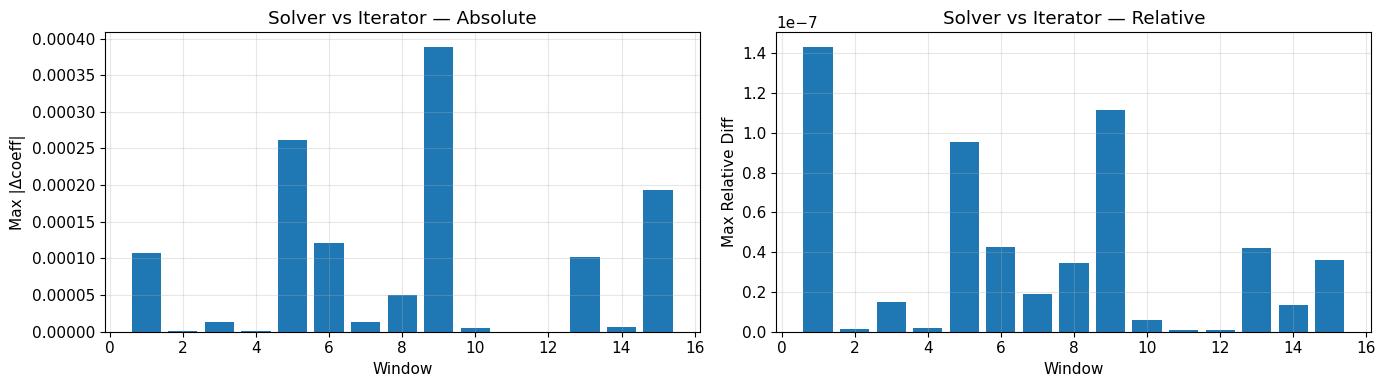

  Solver vs Iterator: max_abs=3.8901e-04, max_rel=1.4343e-07 across 15 windows


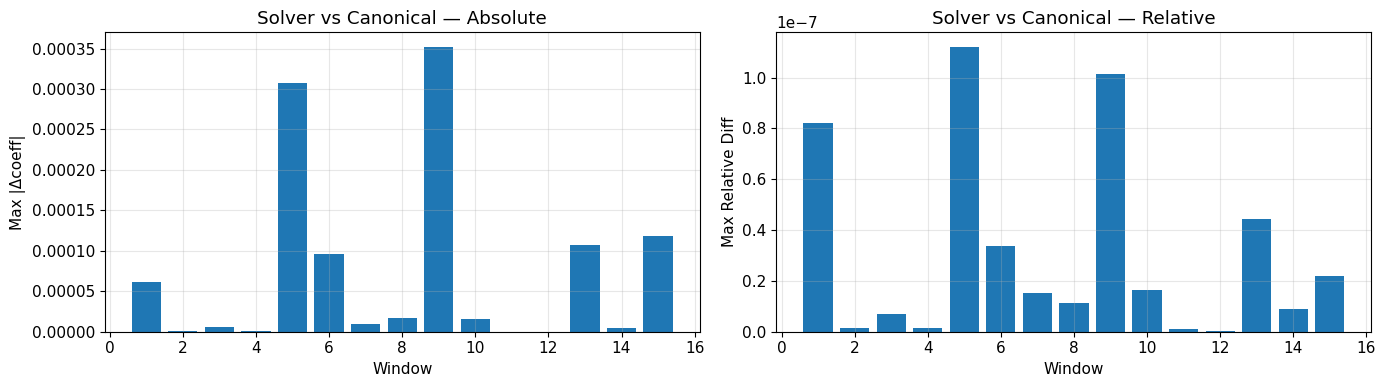

  Solver vs Canonical: max_abs=3.5240e-04, max_rel=1.1223e-07 across 15 windows


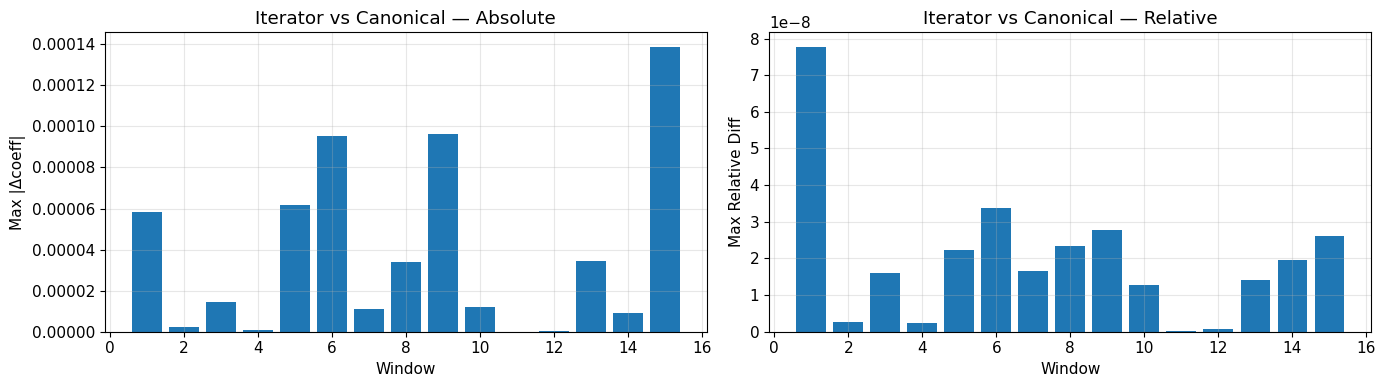

  Iterator vs Canonical: max_abs=1.3884e-04, max_rel=7.7793e-08 across 15 windows


In [37]:
def extract_coefficients(result):
    """Get coefficient vector from a result dict."""
    r = result.get('result', result)
    return np.asarray(r['coefficients'])

# Compare solver vs iterator per-window
pairs_to_compare = []
if 'solver' in window_results and 'iterator' in window_results:
    pairs_to_compare.append(('solver', 'iterator', 'Solver vs Iterator'))
if 'solver' in window_results and 'canonical' in window_results:
    pairs_to_compare.append(('solver', 'canonical', 'Solver vs Canonical'))
if 'iterator' in window_results and 'canonical' in window_results:
    pairs_to_compare.append(('iterator', 'canonical', 'Iterator vs Canonical'))

for a_label, b_label, title in pairs_to_compare:
    max_abs = []
    max_rel = []
    windows_found = []
    for w in range(1, N_WINDOWS + 1):
        ra = window_results[a_label].get(w)
        rb = window_results[b_label].get(w)
        if ra is None or rb is None:
            continue
        ca = extract_coefficients(ra)
        cb = extract_coefficients(rb)
        diff = np.abs(ca - cb)
        max_abs.append(diff.max())
        denom = np.maximum(np.abs(ca), np.abs(cb)).max()
        max_rel.append(diff.max() / denom if denom > 0 else 0.0)
        windows_found.append(w)
    
    if not windows_found:
        print(f'{title}: no overlapping windows')
        continue
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.bar(windows_found, max_abs)
    ax1.set_xlabel('Window'); ax1.set_ylabel('Max |Δcoeff|')
    ax1.set_title(f'{title} — Absolute')
    
    ax2.bar(windows_found, max_rel)
    ax2.set_xlabel('Window'); ax2.set_ylabel('Max Relative Diff')
    ax2.set_title(f'{title} — Relative')
    ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()
    
    print(f'  {title}: max_abs={max(max_abs):.4e}, '
          f'max_rel={max(max_rel):.4e} across {len(windows_found)} windows')

## 4. Combined Coefficient Scatter

Solver vs Iterator: max_abs_diff=1.733950e-09, max_rel_diff=5.558577e-11, n_params=3300
Solver vs Canonical: max_abs_diff=1.676290e-10, max_rel_diff=5.373736e-12, n_params=3300
Iterator vs Canonical: max_abs_diff=1.863017e-09, max_rel_diff=5.972332e-11, n_params=3300


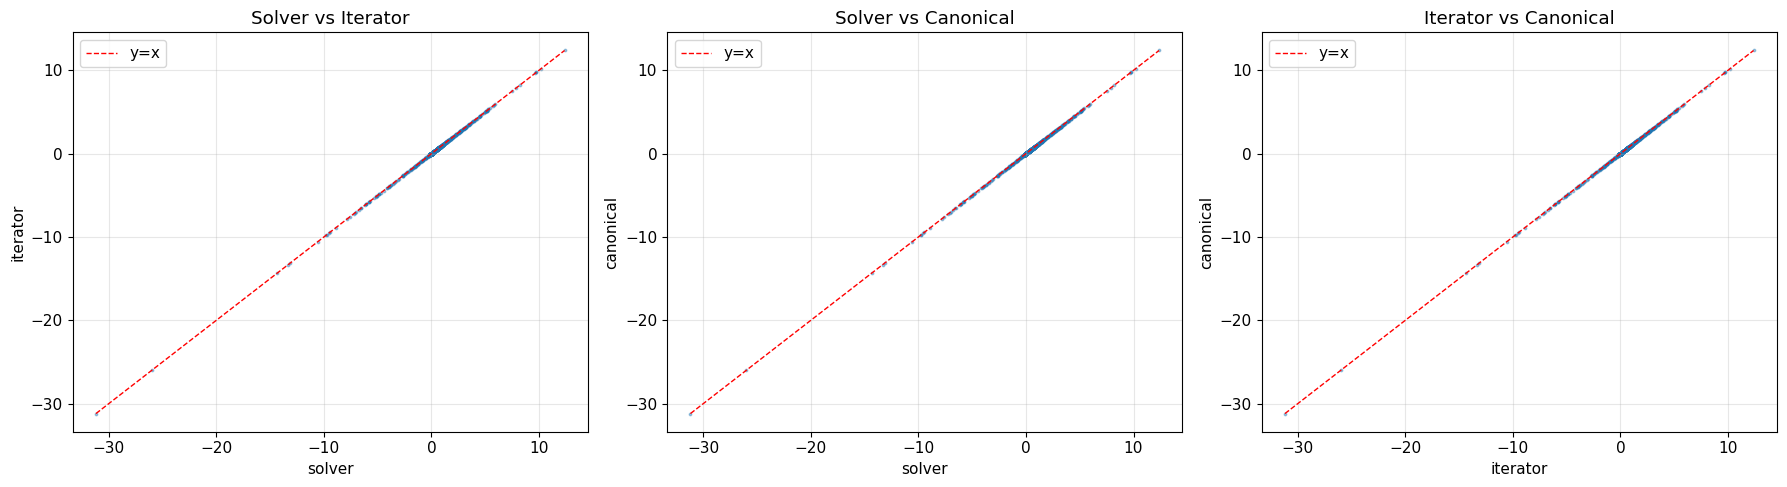

In [38]:
# Scatter: combined coefficients (solver vs iterator vs canonical)
fig, axes = plt.subplots(1, len(pairs_to_compare), figsize=(6*len(pairs_to_compare), 5))
if len(pairs_to_compare) == 1:
    axes = [axes]

for ax, (a_label, b_label, title) in zip(axes, pairs_to_compare):
    ca = combined_results.get(a_label)
    cb = combined_results.get(b_label)
    if ca is None or cb is None:
        ax.text(0.5, 0.5, f'{title}\n(data not available)', ha='center', va='center',
                transform=ax.transAxes)
        continue
    coeff_a = extract_coefficients(ca)
    coeff_b = extract_coefficients(cb)
    
    vmin = min(coeff_a.min(), coeff_b.min())
    vmax = max(coeff_a.max(), coeff_b.max())
    ax.scatter(coeff_a, coeff_b, s=3, alpha=0.4)
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1, label='y=x')
    ax.set_xlabel(a_label)
    ax.set_ylabel(b_label)
    ax.set_title(title)
    ax.legend()
    
    diff = np.abs(coeff_a - coeff_b)
    denom = np.maximum(np.abs(coeff_a), np.abs(coeff_b)).max()
    print(f'{title}: max_abs_diff={diff.max():.6e}, '
          f'max_rel_diff={diff.max()/denom:.6e}, '
          f'n_params={len(coeff_a)}')

plt.tight_layout()
plt.show()

## 5. LAMMPS Table Overlays (V and F)

In [39]:
# Discover table files from any available combined run
table_dirs = {}
for label, root in runs.items():
    if root is None:
        continue
    td = Path(root) / 'combine' / 'tables'
    if td.is_dir():
        table_dirs[label] = td

# Get list of table stems from first available
table_stems = []
for td in table_dirs.values():
    table_stems = sorted([p.stem for p in td.glob('*.table')])
    break

print(f'Table directories: {list(table_dirs.keys())}')
print(f'Table stems ({len(table_stems)}): {table_stems}')

Table directories: ['canonical', 'solver', 'iterator']
Table stems (16): ['HG_HG', 'HG_MG', 'HG_MG_T1_ang', 'HG_MG_bon', 'HG_T1', 'HG_T2', 'MG_MG', 'MG_T1', 'MG_T1_T2_ang', 'MG_T1_bon', 'MG_T2', 'T1_MG_T1_ang', 'T1_T1', 'T1_T2', 'T1_T2_bon', 'T2_T2']


In [40]:
# Group tables by type: pairs, bonds, angles
pair_stems  = [s for s in table_stems if '_bon' not in s and '_ang' not in s]
bond_stems  = [s for s in table_stems if '_bon' in s]
angle_stems = [s for s in table_stems if '_ang' in s]

def plot_table_group(stems, group_name, ncols=5):
    """Plot V(r) and F(r) overlays for a group of tables."""
    if not stems:
        return
    nrows = (len(stems) + ncols - 1) // ncols
    
    # V(r) figure
    fig_v, axes_v = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), squeeze=False)
    fig_v.suptitle(f'{group_name} — V(r)', fontsize=14, y=1.02)
    
    # F(r) figure
    fig_f, axes_f = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), squeeze=False)
    fig_f.suptitle(f'{group_name} — F(r)', fontsize=14, y=1.02)
    
    colors = {'canonical': 'black', 'solver': 'tab:blue', 'iterator': 'tab:orange'}
    
    for idx, stem in enumerate(stems):
        row, col = divmod(idx, ncols)
        ax_v = axes_v[row][col]
        ax_f = axes_f[row][col]
        
        for label, td in table_dirs.items():
            tf = td / f'{stem}.table'
            if not tf.exists():
                continue
            r, V, F = parse_lammps_table(tf)
            c = colors.get(label, 'gray')
            lw = 2.5 if label == 'canonical' else 1.2
            ls = '-' if label == 'canonical' else '--'
            al = 0.6 if label == 'canonical' else 0.9
            ax_v.plot(r, V, color=c, lw=lw, ls=ls, alpha=al, label=label)
            ax_f.plot(r, F, color=c, lw=lw, ls=ls, alpha=al, label=label)
        
        ax_v.set_title(stem, fontsize=10)
        ax_f.set_title(stem, fontsize=10)
        if idx == 0:
            ax_v.legend(fontsize=8)
            ax_f.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(len(stems), nrows * ncols):
        row, col = divmod(idx, ncols)
        axes_v[row][col].set_visible(False)
        axes_f[row][col].set_visible(False)
    
    fig_v.tight_layout()
    fig_f.tight_layout()
    plt.show()

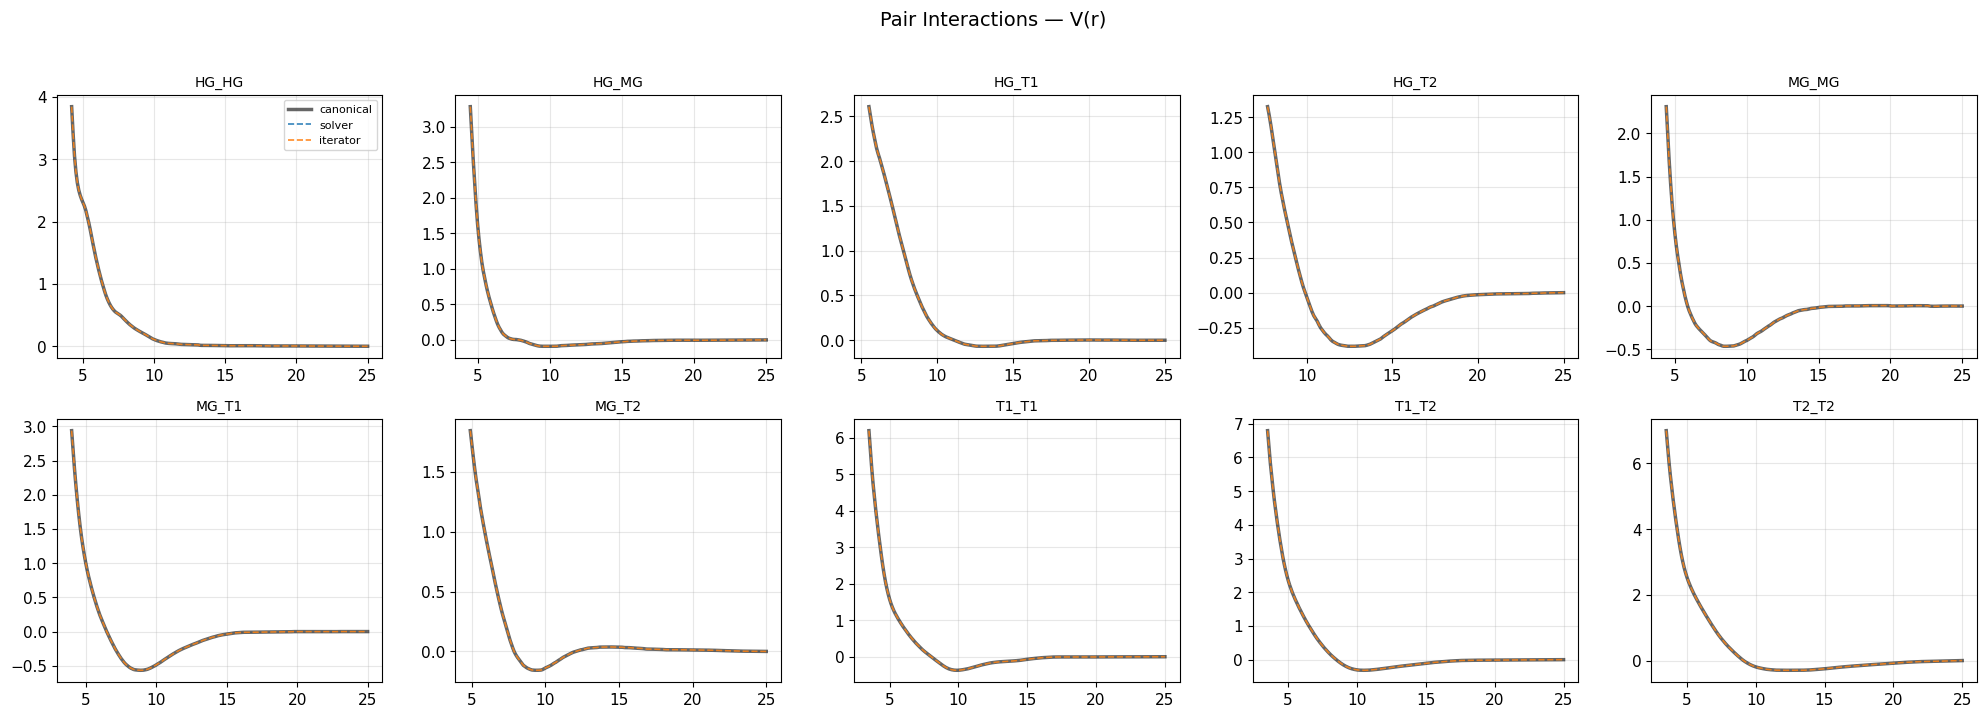

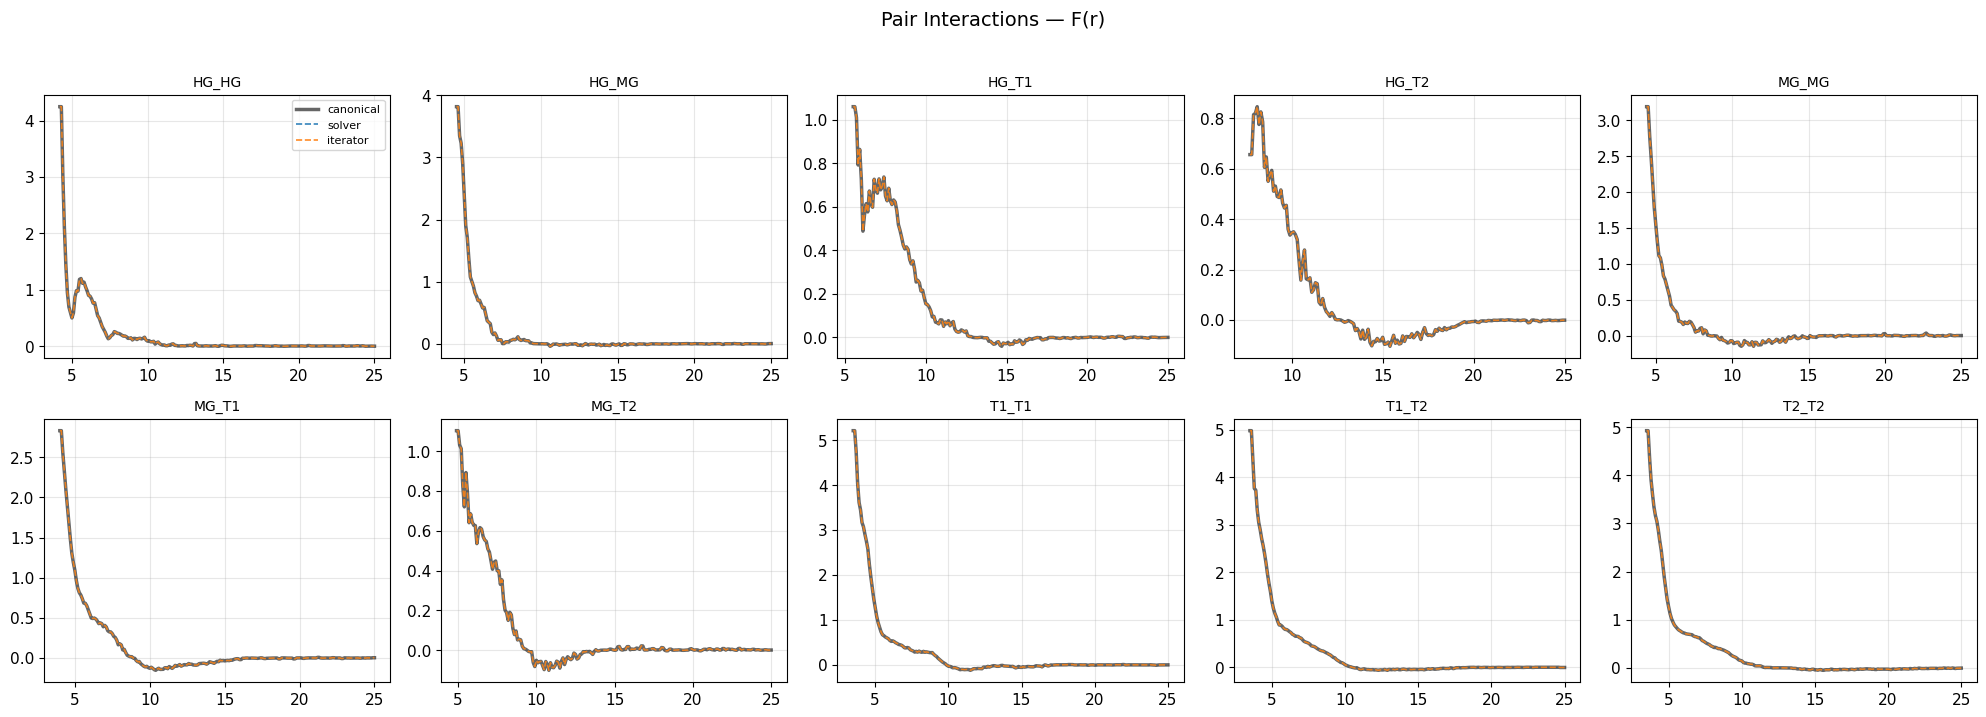

In [41]:
plot_table_group(pair_stems, 'Pair Interactions')

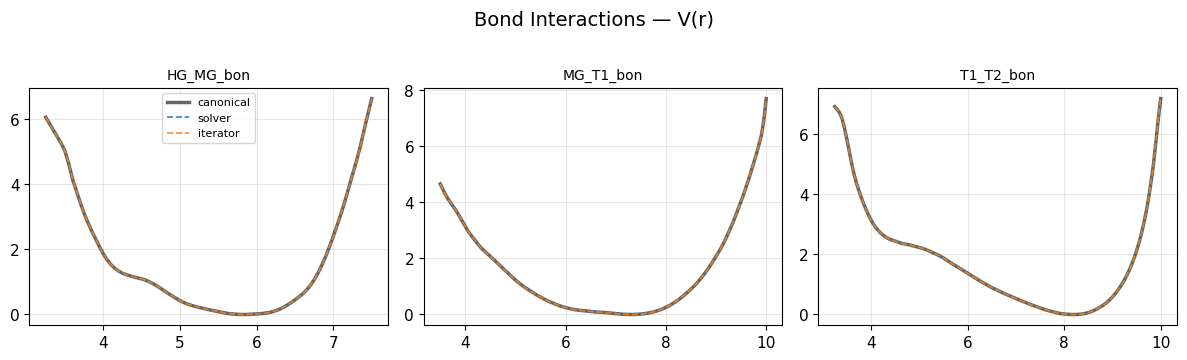

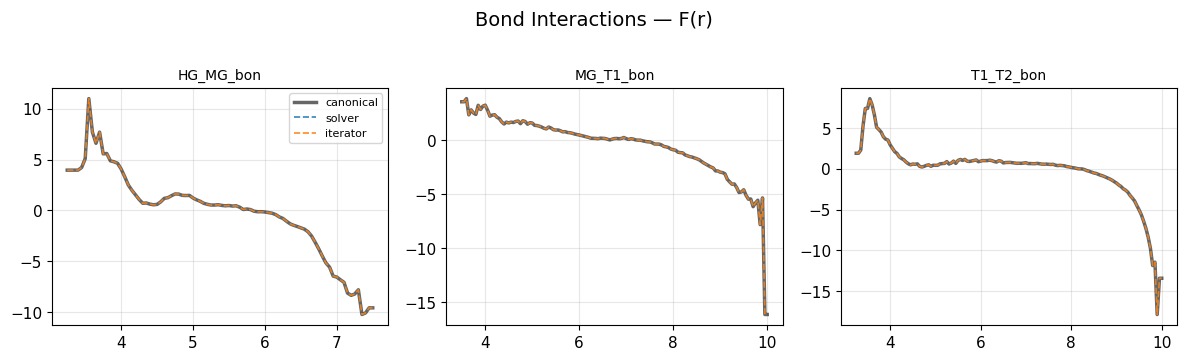

In [42]:
plot_table_group(bond_stems, 'Bond Interactions', ncols=3)

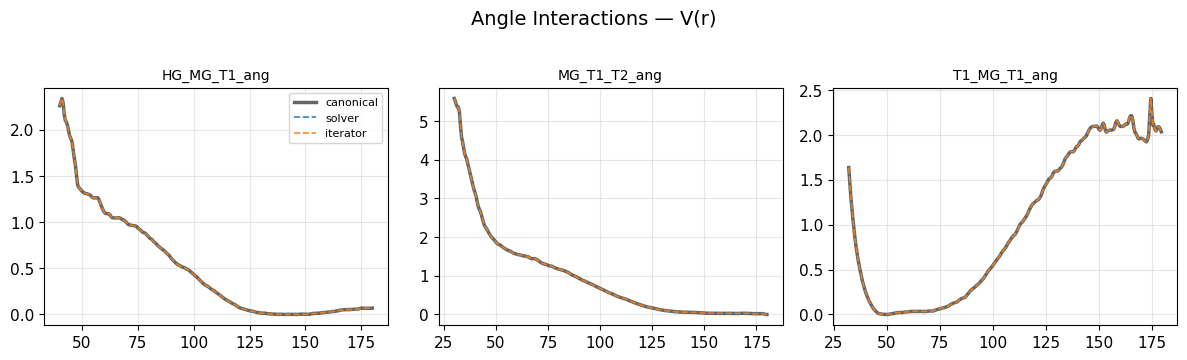

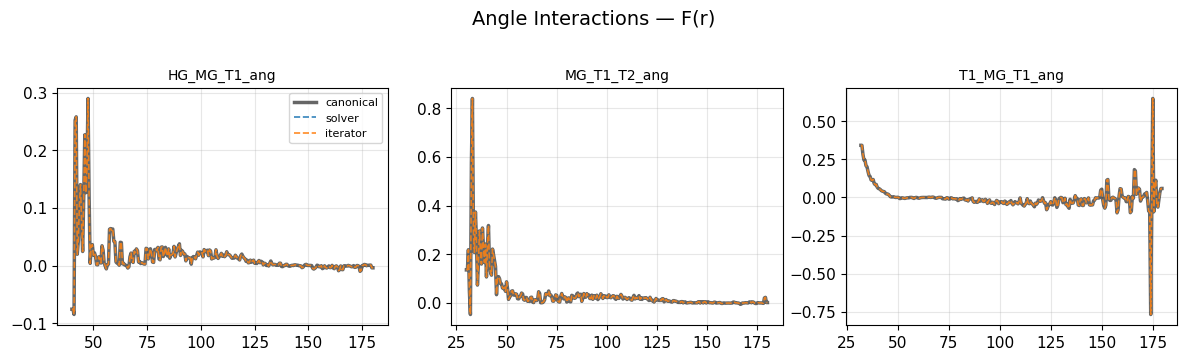

In [43]:
plot_table_group(angle_stems, 'Angle Interactions', ncols=3)

## 6. Table Difference Metrics

In [44]:
# Quantitative table comparison
def compare_tables_quantitative(ref_dir, cand_dir, ref_label, cand_label):
    """Compare all tables between two directories."""
    if ref_dir is None or cand_dir is None:
        return None
    rows = []
    for stem in table_stems:
        ref_path  = ref_dir / f'{stem}.table'
        cand_path = cand_dir / f'{stem}.table'
        if not ref_path.exists() or not cand_path.exists():
            continue
        r_ref, V_ref, F_ref = parse_lammps_table(ref_path)
        r_cand, V_cand, F_cand = parse_lammps_table(cand_path)
        
        # Align on common r range
        n = min(len(r_ref), len(r_cand))
        dV = np.abs(V_ref[:n] - V_cand[:n])
        dF = np.abs(F_ref[:n] - F_cand[:n])
        
        # Find equilibrium (V minimum)
        eq_ref  = r_ref[np.argmin(V_ref)]   if len(V_ref) > 0 else np.nan
        eq_cand = r_cand[np.argmin(V_cand)] if len(V_cand) > 0 else np.nan
        
        rows.append({
            'table': stem,
            'max_dV': dV.max(),
            'mean_dV': dV.mean(),
            'max_dF': dF.max(),
            'mean_dF': dF.mean(),
            'eq_ref': eq_ref,
            'eq_cand': eq_cand,
            'abs_dEQ': abs(eq_ref - eq_cand),
        })
    return rows

# Compare each pair
for a_label, b_label, title in pairs_to_compare:
    td_a = table_dirs.get(a_label)
    td_b = table_dirs.get(b_label)
    rows = compare_tables_quantitative(td_a, td_b, a_label, b_label)
    if rows is None:
        print(f'{title}: no table data available')
        continue
    
    print(f'\n=== {title} ===')
    print(f'{"Table":>20s}  {"max_dV":>10s}  {"max_dF":>10s}  {"dEQ":>8s}')
    print('-' * 55)
    for r in rows:
        print(f'{r["table"]:>20s}  {r["max_dV"]:10.4e}  {r["max_dF"]:10.4e}  '
              f'{r["abs_dEQ"]:8.4f}')


=== Solver vs Iterator ===
               Table      max_dV      max_dF       dEQ
-------------------------------------------------------
               HG_HG  0.0000e+00  0.0000e+00    0.0000
               HG_MG  0.0000e+00  0.0000e+00    0.0000
        HG_MG_T1_ang  0.0000e+00  0.0000e+00    0.0000
           HG_MG_bon  0.0000e+00  0.0000e+00    0.0000
               HG_T1  0.0000e+00  0.0000e+00    0.0000
               HG_T2  0.0000e+00  0.0000e+00    0.0000
               MG_MG  0.0000e+00  0.0000e+00    0.0000
               MG_T1  0.0000e+00  0.0000e+00    0.0000
        MG_T1_T2_ang  0.0000e+00  0.0000e+00    0.0000
           MG_T1_bon  0.0000e+00  0.0000e+00    0.0000
               MG_T2  0.0000e+00  0.0000e+00    0.0000
        T1_MG_T1_ang  0.0000e+00  0.0000e+00    0.0000
               T1_T1  0.0000e+00  0.0000e+00    0.0000
               T1_T2  0.0000e+00  0.0000e+00    0.0000
           T1_T2_bon  0.0000e+00  0.0000e+00    0.0000
               T2_T2  0.0000e+00  0.

## 7. Runtime Benchmarks

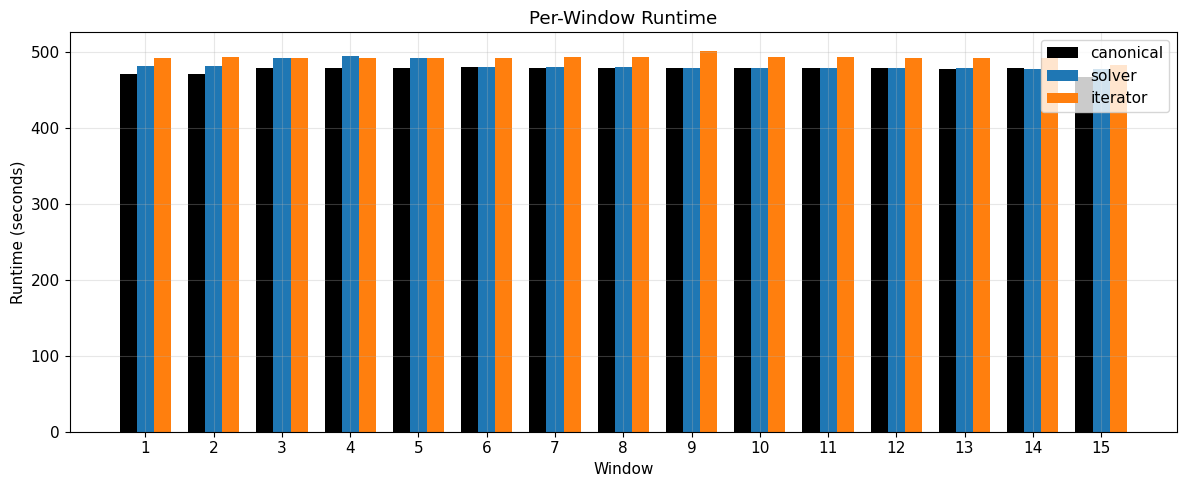

      Engine    Mean (s)     Std (s)     Min (s)     Max (s)
------------------------------------------------------------
   canonical       476.9         3.7       467.3       479.7
      solver       482.2         5.5       477.9       494.5
    iterator       492.6         3.2       483.3       500.8


In [45]:
# Collect per-window runtimes
runtime_data = {}
for label in ['canonical', 'solver', 'iterator']:
    if label not in window_results:
        continue
    times = []
    for w in range(1, N_WINDOWS + 1):
        res = window_results[label].get(w)
        if res is None:
            times.append(np.nan)
            continue
        timing = res.get('timing', {})
        t = timing.get('run_seconds', timing.get('total_seconds', np.nan))
        times.append(t)
    runtime_data[label] = np.array(times)

if runtime_data:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, N_WINDOWS + 1)
    width = 0.25
    colors = {'canonical': 'black', 'solver': 'tab:blue', 'iterator': 'tab:orange'}
    for i, (label, times) in enumerate(runtime_data.items()):
        ax.bar(x + i * width, times, width, label=label, color=colors.get(label, 'gray'))
    ax.set_xlabel('Window')
    ax.set_ylabel('Runtime (seconds)')
    ax.set_title('Per-Window Runtime')
    ax.set_xticks(x + width)
    ax.set_xticklabels(x)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Summary table
print(f'{"Engine":>12s}  {"Mean (s)":>10s}  {"Std (s)":>10s}  {"Min (s)":>10s}  {"Max (s)":>10s}')
print('-' * 60)
for label, times in runtime_data.items():
    valid = times[~np.isnan(times)]
    if len(valid) > 0:
        print(f'{label:>12s}  {valid.mean():10.1f}  {valid.std():10.1f}  '
              f'{valid.min():10.1f}  {valid.max():10.1f}')

In [46]:
# Combine-stage timing
print('\nCombine-stage timing:')
for label in ['canonical', 'solver', 'iterator']:
    s = summaries.get(label)
    if s is None:
        continue
    solve_t = s.get('solve_seconds', '?')
    total_t = s.get('total_seconds', s.get('combine_seconds', '?'))
    bayesian = s.get('bayesian_iterations', '?')
    print(f'  {label}: solve={solve_t}s, total={total_t}s, '
          f'bayesian_iters={bayesian}')


Combine-stage timing:
  canonical: solve=23.56528353318572s, total=?s, bayesian_iters=?
  solver: solve=34.10804777871817s, total=?s, bayesian_iters=?
  iterator: solve=34.3463447149843s, total=?s, bayesian_iters=?


## 8. XtX / XtY Matrix Parity (Per-Window)

In [47]:
def extract_matrix(result, key):
    """Extract XtX or XtY from result."""
    r = result.get('result', result)
    m = r.get('matrix', {})
    val = m.get(key)
    return np.asarray(val) if val is not None else None

# Compare XtX/XtY between solver and canonical
for a_label, b_label in [('solver', 'canonical'), ('iterator', 'canonical'),
                          ('solver', 'iterator')]:
    if a_label not in window_results or b_label not in window_results:
        continue
    
    xtx_diffs = []
    xty_diffs = []
    for w in range(1, N_WINDOWS + 1):
        ra = window_results[a_label].get(w)
        rb = window_results[b_label].get(w)
        if ra is None or rb is None:
            continue
        
        XtX_a = extract_matrix(ra, 'XtX')
        XtX_b = extract_matrix(rb, 'XtX')
        XtY_a = extract_matrix(ra, 'XtY')
        XtY_b = extract_matrix(rb, 'XtY')
        
        if XtX_a is not None and XtX_b is not None:
            xtx_diffs.append(np.abs(XtX_a - XtX_b).max())
        if XtY_a is not None and XtY_b is not None:
            xty_diffs.append(np.abs(XtY_a - XtY_b).max())
    
    print(f'{a_label} vs {b_label}:')
    if xtx_diffs:
        print(f'  XtX max_abs_diff (across windows): {max(xtx_diffs):.6e}')
    if xty_diffs:
        print(f'  XtY max_abs_diff (across windows): {max(xty_diffs):.6e}')

solver vs canonical:
  XtX max_abs_diff (across windows): 9.313226e-10
  XtY max_abs_diff (across windows): 5.820766e-11
iterator vs canonical:
  XtX max_abs_diff (across windows): 9.313226e-10
  XtY max_abs_diff (across windows): 5.820766e-11
solver vs iterator:
  XtX max_abs_diff (across windows): 9.313226e-10
  XtY max_abs_diff (across windows): 5.820766e-11


## 9. Summary Report

In [48]:
print('=' * 60)
print('  FM PARITY ANALYSIS SUMMARY')
print('=' * 60)

for label, root in runs.items():
    n_win = len(window_results.get(label, {}))
    has_combined = combined_results.get(label) is not None
    has_tables = label in table_dirs
    print(f'\n  {label}:')
    print(f'    root     : {root}')
    print(f'    windows  : {n_win}/{N_WINDOWS}')
    print(f'    combined : {has_combined}')
    print(f'    tables   : {has_tables}')

print('\n  Parity checks:')
for a_label, b_label, title in pairs_to_compare:
    ca = combined_results.get(a_label)
    cb = combined_results.get(b_label)
    if ca is not None and cb is not None:
        coeff_a = extract_coefficients(ca)
        coeff_b = extract_coefficients(cb)
        diff = np.abs(coeff_a - coeff_b)
        denom = np.maximum(np.abs(coeff_a), np.abs(coeff_b)).max()
        print(f'    {title}: max_abs={diff.max():.4e}, max_rel={diff.max()/denom:.4e}')
    else:
        print(f'    {title}: INCOMPLETE (waiting for results)')

print('\n' + '=' * 60)

  FM PARITY ANALYSIS SUMMARY

  canonical:
    root     : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/final_20260304_2230
    windows  : 15/15
    combined : True
    tables   : True

  solver:
    root     : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/solver_20260306_000145
    windows  : 15/15
    combined : True
    tables   : True

  iterator:
    root     : /beagle3/gavoth/weizhixue/programs/AceCG/tests/_runs/iterator_20260306_000151
    windows  : 15/15
    combined : True
    tables   : True

  Parity checks:
    Solver vs Iterator: max_abs=1.7339e-09, max_rel=5.5586e-11
    Solver vs Canonical: max_abs=1.6763e-10, max_rel=5.3737e-12
    Iterator vs Canonical: max_abs=1.8630e-09, max_rel=5.9723e-11

